In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
df=pd.read_csv("/content/Heart_dataset.csv")

In [153]:
df.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [154]:
df=df.drop('Unnamed: 0',axis=1)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 33.3+ KB


In [156]:
df.describe(include='object')

,ChestPain,Thal,AHD
count,303,301,303
unique,4,3,2
top,asymptomatic,normal,No
freq,144,166,164


In [157]:
df.describe(exclude='object')

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000
mean,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241
std,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


In [158]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPain,0
RestBP,0
Chol,0
Fbs,0
RestECG,0
MaxHR,0
ExAng,0
Oldpeak,0


In [159]:
df['Ca']=df['Ca'].fillna(df['Ca'].mean())
df['Thal']=df['Thal'].fillna(df['Thal'].mode()[0])

In [160]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPain,0
RestBP,0
Chol,0
Fbs,0
RestECG,0
MaxHR,0
ExAng,0
Oldpeak,0


In [161]:
df.duplicated().sum()

np.int64(0)

In [162]:
df.drop_duplicates(inplace=True)

<Axes: xlabel='Sex', ylabel='count'>

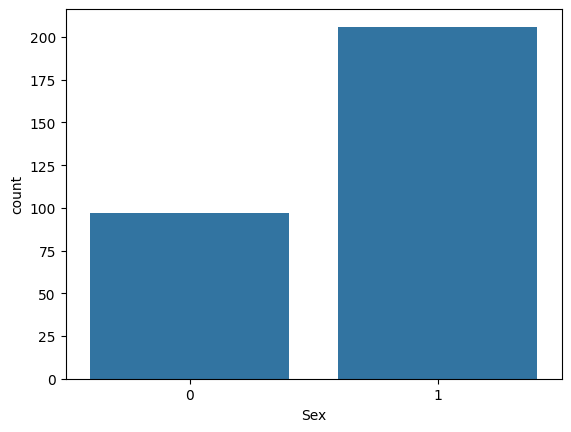

In [163]:
sns.countplot(x=df['Sex'])

<Axes: xlabel='Age', ylabel='Count'>

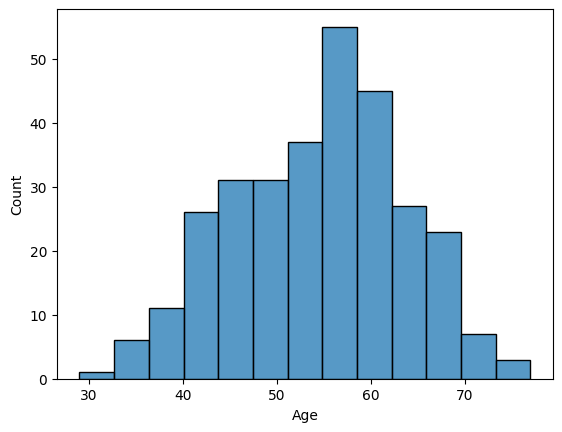

In [164]:
sns.histplot(x=df['Age'])

<Axes: xlabel='ChestPain', ylabel='count'>

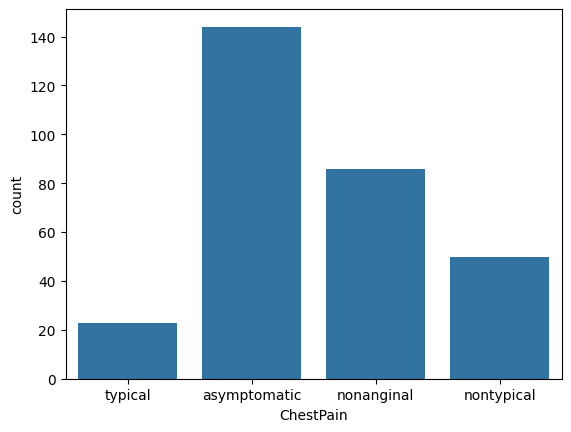

In [165]:
sns.countplot(x=df['ChestPain'])

<Axes: xlabel='RestBP', ylabel='Count'>

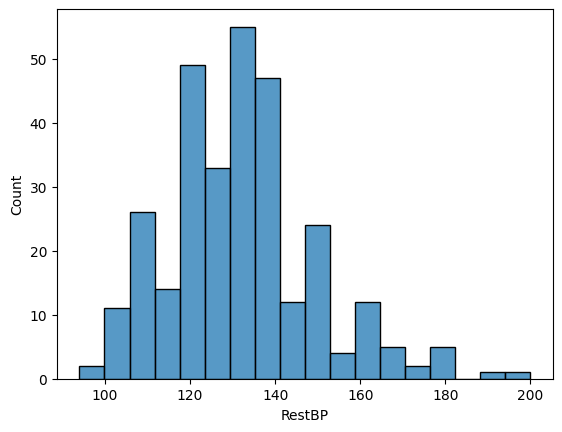

In [166]:
sns.histplot(x=df['RestBP'])

<Axes: xlabel='Chol', ylabel='Count'>

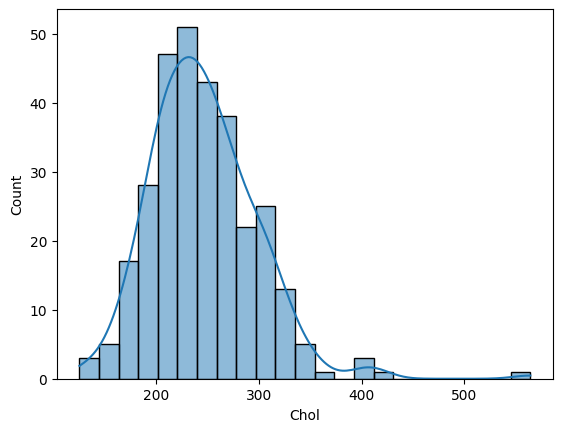

In [167]:
sns.histplot(x=df['Chol'],kde=True)

<Axes: xlabel='RestBP'>

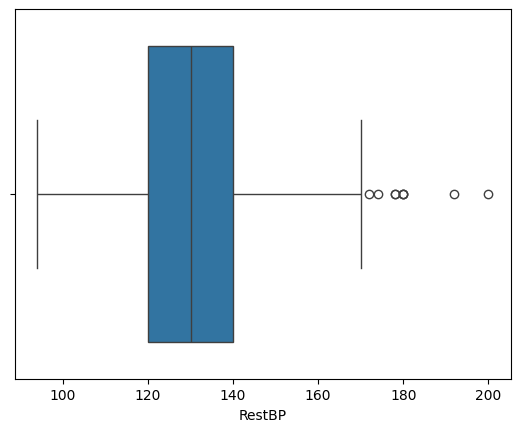

In [168]:
sns.boxplot(x=df['RestBP'])

In [169]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df=pd.get_dummies(df,columns=['ChestPain','Thal','AHD'],drop_first=True)

df=df.astype(int)

In [170]:
df.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable,AHD_Yes
0,63,1,145,233,1,2,150,0,2,3,0,0,0,1,0,0,0
1,67,1,160,286,0,2,108,1,1,2,3,0,0,0,1,0,1
2,67,1,120,229,0,2,129,1,2,2,2,0,0,0,0,1,1
3,37,1,130,250,0,0,187,0,3,3,0,1,0,0,1,0,0
4,41,0,130,204,0,2,172,0,1,1,0,0,1,0,1,0,0


<Axes: xlabel='AHD_Yes', ylabel='count'>

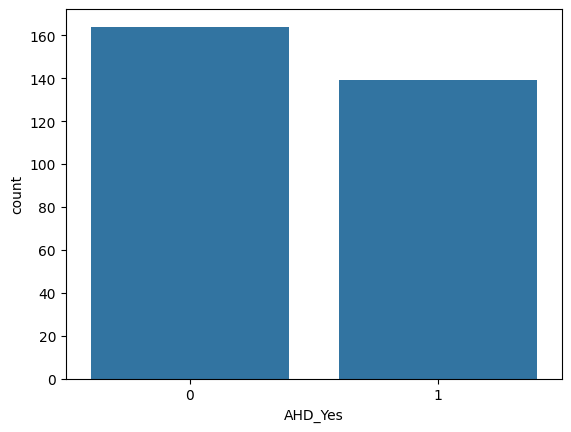

In [172]:
sns.countplot(x=df['AHD_Yes'])

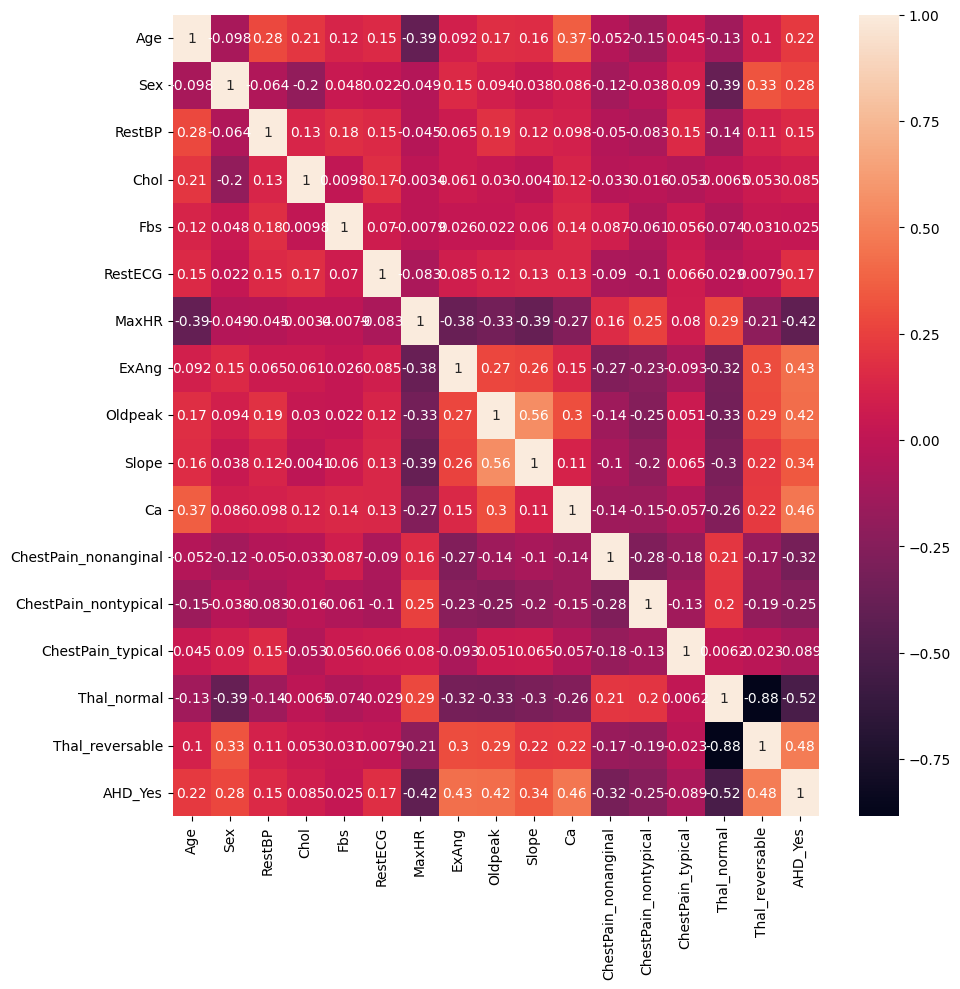

In [173]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.tight_layout()

In [175]:
x=df.drop('AHD_Yes',axis=1)
y=df['AHD_Yes']


In [176]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [177]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [178]:
x_train

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
132,29,1,130,204,0,2,202,0,0,1,0,0,1,0,1,0
202,57,1,150,126,1,0,173,0,0,1,1,1,0,0,0,1
196,69,1,160,234,1,2,131,0,0,2,1,0,0,1,1,0
75,65,0,160,360,0,2,151,0,0,1,0,1,0,0,1,0
176,52,1,108,233,1,0,147,0,0,1,3,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,54,1,192,283,0,2,195,0,0,1,1,0,1,0,0,1
71,67,1,125,254,1,0,163,0,0,2,2,0,0,0,0,1
106,59,1,140,177,0,0,162,1,0,1,1,0,0,0,0,1
270,61,1,140,207,0,2,138,1,1,1,1,0,0,0,0,1


In [179]:
lr=LogisticRegression()
lr.fit(x_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [180]:
y_pred=lr.predict(x_test)

In [181]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [182]:
accuracy_score(y_test,y_pred)

0.9180327868852459

In [183]:
confusion_matrix(y_test,y_pred)

array([[27,  2],
       [ 3, 29]])

In [184]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [185]:
sv=SVC()
sv.fit(x_train,y_train)


SVC()

In [186]:
y_pred=sv.predict(x_test)

In [187]:
accuracy_score(y_test,y_pred)

0.6721311475409836

In [188]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.60      0.90      0.72        29
           1       0.83      0.47      0.60        32

    accuracy                           0.67        61
   macro avg       0.72      0.68      0.66        61
weighted avg       0.72      0.67      0.66        61



In [189]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)


RandomForestClassifier()

In [190]:
y_pred=rf.predict(x_test)


In [191]:
accuracy_score(y_test,y_pred)

0.9016393442622951

In [129]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

